<a href="https://colab.research.google.com/github/glenpaulson/toxicity-mining-nlp/blob/main/group_11_toxicity_mining_nlp_milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning & Preprocessing

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from matplotlib import rcParams
# from plotly.offline import init_notebook_mode
# init_notebook_mode(connected=True)
import plotly.express as px
import warnings
import time
import datetime as dt
warnings.filterwarnings("ignore")
from typing import Optional, Tuple, List, Any
from datasets import load_dataset

# Customizations

In [2]:
class Print:
    """
    Colourful console output using ANSI escape codes.
    Provides methods for info, success, warning, error, etc.
    """
    _RESET = '\033[0m'
    _BOLD = '\033[1m'
    _DIVIDER = '=' * 70

    # ANSI colour codes
    _CYAN = '\033[96m'
    _GREEN = '\033[92m'
    _YELLOW = '\033[93m'
    _RED = '\033[91m'
    _MAGENTA = '\033[95m'
    _BLUE = '\033[94m'
    @classmethod
    def _print(cls, colour: str, symbol: str, *args, **kwargs):
        """Base print method with colour and symbol."""
        message = ' '.join(str(a) for a in args)
        print(f"{cls._BOLD}{colour}{symbol} {message}{cls._RESET}", **kwargs)

    @classmethod
    def info(cls, *args, **kwargs):
        cls._print(cls._CYAN, '[i]', *args, **kwargs)

    @classmethod
    def success(cls, *args, **kwargs):
        cls._print(cls._GREEN, '[✓]', *args, **kwargs)

    @classmethod
    def warning(cls, *args, **kwargs):
        cls._print(cls._YELLOW, '[!]', *args, **kwargs)

    @classmethod
    def error(cls, *args, **kwargs):
        cls._print(cls._RED, '[✗]', *args, **kwargs)

    @classmethod
    def header(cls, *args, **kwargs):
        """Print a section header with a divider."""
        print()
        cls._print(cls._MAGENTA, '---', *args, **kwargs)
        print(cls._DIVIDER)

    @classmethod
    def divider(cls):
        print(cls._DIVIDER)

    @classmethod
    def blank(cls):
        print()


In [3]:
def print_table(df: pd.DataFrame, title: Optional[str] = None, max_rows: int = 20):
    """
    Display a styled DataFrame in Jupyter.
    """

    df_disp = df.head(max_rows).copy()

    # Detect column types
    num_cols = df_disp.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df_disp.select_dtypes(include=["object", "category"]).columns.tolist()

    styled = df_disp.style

    # Base Table Styling
    styled = styled.set_table_styles(
        [
            {
                "selector": "th",
                "props": [("background-color", "#2f3e46"),("color", "white"),("font-weight", "bold"),("text-align", "center"),("border", "1px solid #dddddd"),
                ],
            },
             {
                "selector": "td",
                "props": [("border", "1px solid #eeeeee"),("padding", "6px"),("text-align", "center"),
                ],
            },
            {
                "selector": "tr:hover",
                "props": [("background-color", "#f1f3f5")],
            },
        ]
    )
    # Numeric Styling
    if num_cols:
        styled = styled.background_gradient(
            cmap="Blues",
            subset=num_cols
        ).format(precision=3)

    # Categorical Styling
    if cat_cols:
        styled = styled.set_properties(
            subset=cat_cols,
            **{
                "background-color": "#fdf6e3",  # soft beige
                "color": "#333333",
            }
        )
        # Caption
    if title:
        styled = styled.set_caption(title).set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "16px"),
                        ("font-weight", "bold"),
                        ("padding", "8px"),
                    ],
                }
            ],
            overwrite=False,
        )

    display(styled)



In [4]:
def set_plot_style():
    rcParams['figure.figsize'] = (12, 6)
    rcParams['axes.facecolor'] = '#f8f9fa'
    rcParams['figure.facecolor'] = 'white'
    rcParams['axes.grid'] = True
    rcParams['grid.alpha'] = 0.3
    rcParams['grid.color'] = '#cccccc'
    rcParams['axes.edgecolor'] = '#333333'
    rcParams['axes.linewidth'] = 1.2
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.size'] = 11
    rcParams['axes.labelsize'] = 12
    rcParams['axes.titlesize'] = 14
    rcParams['axes.titleweight'] = 'bold'
    rcParams['xtick.labelsize'] = 10
    rcParams['ytick.labelsize'] = 10
    rcParams['legend.fontsize'] = 10
    rcParams['legend.framealpha'] = 0.9

    # Custom colour palette
      # Custom colour palette
    global COLORS
    COLORS = ['#1e3c72', '#c31432', '#9D4EDD', '#C77DFF', '#E0AAFF', '#5A189A', '#240046']

    # Set seaborn palette
    sns.set_palette(sns.color_palette(COLORS))

    # Apply to matplotlib
    plt.rcParams.update(rcParams)

# Loading datasets

## Loading google civil comments dataset

In [5]:
dataset_jigsaw = load_dataset("google/civil_comments")
df_jigsaw = dataset_jigsaw["train"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

In [6]:
print_table(df_jigsaw.head(10),"Jigsaw dataset overview")

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!",0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,"Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!",0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,This is such an urgent design problem; kudos to you for taking it on. Very impressive!,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,Is this something I'll be able to install on my site? When will you be releasing it?,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,haha you guys are a bunch of losers.,0.894,0.021,0.000,0.000,0.872,0.021,0.000
5,ur a sh*tty comment.,0.667,0.048,0.638,0.000,0.333,0.000,0.010
6,hahahahahahahahhha suck it.,0.458,0.051,0.305,0.000,0.254,0.000,0.220
7,FFFFUUUUUUUUUUUUUUU,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,The ranchers seem motivated by mostly by greed; no one should have the right to allow their animals destroy public land.,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,It was a great show. Not a combo I'd of expected to be good together but it was.,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## Loading tweet eval dataset

In [7]:
dataset_twitter = load_dataset("cardiffnlp/tweet_eval", "hate")

README.md: 0.00B [00:00, ?B/s]

hate/train-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
df_twitter = dataset_twitter["train"].to_pandas()

In [9]:
print_table(df_twitter.head(5), "Twitter dataset overview")


,text,label
0,@user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you…,0
1,A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎,1
2,@user @user real talk do you have eyes or were they gouged out by a rapefugee?,1
3,your girlfriend lookin at me like a groupie in this bitch!,1
4,Hysterical woman like @user,0


# Handling issues or noise in the data

## Handling missing values

In [10]:
missing_df_jigsaw = (df_jigsaw.isnull().sum()/df_jigsaw.shape[0]).reset_index()
missing_df_jigsaw.columns = ['Feature','Missing values % ']

In [11]:
missing_df_twitter = (df_twitter.isnull().sum()/df_jigsaw.shape[0]).reset_index()
missing_df_twitter.columns = ['Feature','Missing values % ']

In [12]:
Print.header("Handling Missing Values")
print_table(missing_df_jigsaw,"Missing values in jigsaw dataset")
print("\n")
print_table(missing_df_twitter,"Missing values in twitter dataset")


--- Handling Missing Values


,Feature,Missing values %
0,text,0.000
1,toxicity,0.000
2,severe_toxicity,0.000
3,obscene,0.000
4,threat,0.000
5,insult,0.000
6,identity_attack,0.000
7,sexual_explicit,0.000


,Feature,Missing values %
0,text,0.000
1,label,0.000


**Inference**:

There are no missing (null) values in the both datasets.

## Handling duplicate values

### Jigsaw Dataset

**Duplicate values check**

In [13]:
print_table(df_jigsaw[df_jigsaw.duplicated()], "Duplicate values overview for jigsaw dataset")

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
611,"While stumping for the bond money the powers that be TOLD voters they would use the money to build a reserve, but they counted on us not to read the fine print describing what actually would occur; there is no mention of the reserve in writing!",0.000,0.000,0.000,0.000,0.000,0.000,0.000
668,"I have eaten at the Imperial and enjoyed the experience, the food was fantastic and the staff were helpful and well trained.",0.000,0.000,0.000,0.000,0.000,0.000,0.000
943,"No. Not legal under OLCC regulations! See under FAQs... ""Q: Can I have a drive thru window if I’m approved for a retail license? A: No, drive thru windows are prohibited by statute."" http://www.oregon.gov/olcc/marijuana/pages/frequently-asked-questions.aspx",0.000,0.000,0.000,0.000,0.000,0.000,0.000
984,"You are incorrect. The land is part of the Willamette Greenway Trail Program established in 1967 Oregon legislature as a public right of way and owned my the city. The 1973 Oregon legislature passed the Willamette River Greenway Act see the text of the law here http://www.oregon.gov/LCD/docs/goals/goal15.pdf If you look at the map you will note the trails name is ""Willamette Greenway Trail"" this is not coincidence. Making repairs does in no way allow for the McCormick Pier condominium to take possession of public land. If you bothered to do any research you would have hit upon this fact.",0.000,0.000,0.000,0.000,0.000,0.000,0.000
985,"You are incorrect. The land is part of the Willamette Greenway Trail Program established in 1967 Oregon legislature as a public right of way and owned my the city. The 1973 Oregon legislature passed the Willamette River Greenway Act see the text of the law here http://www.oregon.gov/LCD/docs/goals/goal15.pdf If you look at the map you will note the trails name is ""Willamette Greenway Trail"" this is not coincidence. Making repairs does in no way allow for the McCormick Pier condominium to take possession of public land. If you bothered to do any research you would have hit upon this fact.",0.000,0.000,0.000,0.000,0.000,0.000,0.000
986,"You are incorrect. The land is part of the Willamette Greenway Trail Program established in 1967 Oregon legislature as a public right of way and owned my the city. The 1973 Oregon legislature passed the Willamette River Greenway Act see the text of the law here http://www.oregon.gov/LCD/docs/goals/goal15.pdf If you look at the map you will note the trails name is ""Willamette Greenway Trail"" this is not coincidence. Making repairs does in no way allow for the McCormick Pier condominium to take possession of public land. If you bothered to do any research you would have hit upon this fact.",0.000,0.000,0.000,0.000,0.000,0.000,0.000
998,This is a test comment (trying out the new Civil Comments platform for an article).,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1910,"Please raise your hand if you are surprised,,,",0.000,0.000,0.000,0.000,0.000,0.000,0.000
5557,Agreed.,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7404,Watch Nancy Reagan’s Funeral Live Stream===>>>http://imgur.com/rxY5xuL,0.000,0.000,0.000,0.000,0.000,0.000,0.000


**Number of duplicate values**

In [14]:
# Count exact duplicate rows
duplicate_count = df_jigsaw.duplicated().sum()
Print.success("Number of exact duplicate rows:", duplicate_count)

[✓] Number of exact duplicate rows: 17955


**Shape before dropping duplicate values**

In [15]:
Print.success("Shape before dropping duplicates:", df_jigsaw.shape)

[✓] Shape before dropping duplicates: (1804874, 8)


**Dropping exact duplicates**

In [16]:
df_jigsaw = df_jigsaw.drop_duplicates()

**Shape after dropping duplicate values**

In [17]:
Print.success("Shape after dropping duplicates:", df_jigsaw.shape)

[✓] Shape after dropping duplicates: (1786919, 8)


### Twitter Dataset

**Duplicate values overview**

In [18]:
print_table(df_twitter[df_twitter.duplicated()], "Duplicate values overview for twitter dataset")

,text,label
1982,,0
3011,@user Fuck you pussy,0
3166,@user @user @user @user @user @user @user @user @user @user @user @user @user @user @user @user @user @user @user @user,0
3843,,0
6338,The woman who #accused nelly of #rape has dropped her case.,0
6643,,0
6791,,0
7114,,0
7176,RT @user 😂😂😂,0
7236,@user @user Bitch shut the fuck up,1


**Number of duplicate values**

In [19]:
duplicate_count = df_twitter.duplicated().sum()
Print.success("Number of exact duplicate rows:", duplicate_count)

[✓] Number of exact duplicate rows: 12


**Shape before dropping duplicate rows**

In [20]:
Print.success("Shape before dropping duplicates:", df_twitter.shape)

[✓] Shape before dropping duplicates: (9000, 2)


**Dropping exact duplicates**

In [21]:
df_twitter = df_twitter.drop_duplicates()

**Shape after dropping duplicate values**

In [22]:
Print.success("Shape before dropping duplicates:", df_twitter.shape)

[✓] Shape before dropping duplicates: (8988, 2)


## Dropping whitespaces and extremely small sentences

In [23]:
def clean_short_and_empty(df: pd.DataFrame, text_col: str, min_words: int = 3):

    before_shape = df.shape
    before_rows = len(df)

    # safe string series
    s = df[text_col].fillna("").astype(str)

    empty_mask = s.str.strip().eq("")
    word_count = s.str.strip().str.split().apply(len)
    short_mask = (~empty_mask) & (word_count < min_words)

    stats = {
        "before_shape": before_shape,
        "empty_rows": int(empty_mask.sum()),
        f"short_rows_<{min_words}_words": int(short_mask.sum()),
        "total_rows_before": before_rows
    }

    keep_mask = (~empty_mask) & (word_count >= min_words)
    df_clean = df.loc[keep_mask].copy()
    df_clean["word_count"] = word_count[keep_mask].values

    stats.update({
        "after_shape": df_clean.shape,
        "total_rows_after": len(df_clean),
        "rows_removed": before_rows - len(df_clean),
        "pct_removed": round((before_rows - len(df_clean)) / max(before_rows, 1) * 100, 2)
    })

    return df_clean, stats

In [24]:

# ---- JIGSAW ----
TEXT_COL_JIGSAW = "text"   # change if needed
df_jigsaw, jigsaw_stats = clean_short_and_empty(df_jigsaw, TEXT_COL_JIGSAW, min_words=3)

Print.header("JIGSAW CLEANING SUMMARY")
for k, v in jigsaw_stats.items():
    print(f"{k}: {v}")


--- JIGSAW CLEANING SUMMARY
before_shape: (1786919, 8)
empty_rows: 0
short_rows_<3_words: 21588
total_rows_before: 1786919
after_shape: (1765331, 9)
total_rows_after: 1765331
rows_removed: 21588
pct_removed: 1.21


In [25]:
# ---- TWEET EVAL ----
TEXT_COL_TWEET = "text"   # change if needed
df_twitter, tweet_stats = clean_short_and_empty(df_twitter, TEXT_COL_TWEET, min_words=3)

Print.header("TWEET EVAL CLEANING SUMMARY")
for k, v in tweet_stats.items():
    print(f"{k}: {v}")


--- TWEET EVAL CLEANING SUMMARY
before_shape: (8988, 2)
empty_rows: 1
short_rows_<3_words: 33
total_rows_before: 8988
after_shape: (8954, 3)
total_rows_after: 8954
rows_removed: 34
pct_removed: 0.38


## Handling outliers

In [26]:
def set_clean_style():
    sns.set_style("darkgrid")

    rcParams["figure.figsize"] = (10,5)
    rcParams["axes.facecolor"] = "#f2f2f2"
    rcParams["grid.color"] = "#d0d0d0"
    rcParams["grid.alpha"] = 0.5

    rcParams["axes.titlesize"] = 14
    rcParams["axes.titleweight"] = "bold"
    rcParams["axes.labelsize"] = 11

In [27]:
def clean_boxplot(df, column, title):
    set_clean_style()
    sns.boxplot(
        y=df[column],
        width=0.35,
        color="#1C77C3",   # dark blue box
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="#F1D302", linewidth=2),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=5,
            alpha=0.9
        )
    )

    plt.title(title)
    plt.ylabel(column)
    plt.xlabel("")

    plt.tight_layout()
    plt.show()

In [28]:
def handle_outliers(df, title, drop_outliers):

  Print.header('Visulaize Outliers using boxplot')
  clean_boxplot(df, "word_count", "Distribution of word count")
  Print.header('Handle outliers using IQR method')
  before_shape = df.shape
  q3 =  df['word_count'].quantile(0.75)
  q1 =  df['word_count'].quantile(0.25)
  IQR = q3-q1
  upper_bound = q3 + 1.5*IQR
  lower_bound = q1 - 1.5*IQR
  outlier_mask = (df["word_count"] < lower_bound) | (df["word_count"] > upper_bound)
  outlier_count = int(outlier_mask.sum())

  print(f"=== {title} | Outlier Report ({'word_count'}) ===")
  Print.success("Shape before:", before_shape)
  Print.success("Outliers detected:", outlier_count)
  Print.success("Lower bound:", round(lower_bound, 2))
  Print.success("Upper bound:", round(upper_bound, 2))
  if drop_outliers:
        df_clean = df.loc[~outlier_mask].copy()
        print("Shape after:", df_clean.shape)
        print("Rows removed:", before_shape[0] - df_clean.shape[0])
        return df_clean

  return df



--- Visulaize Outliers using boxplot


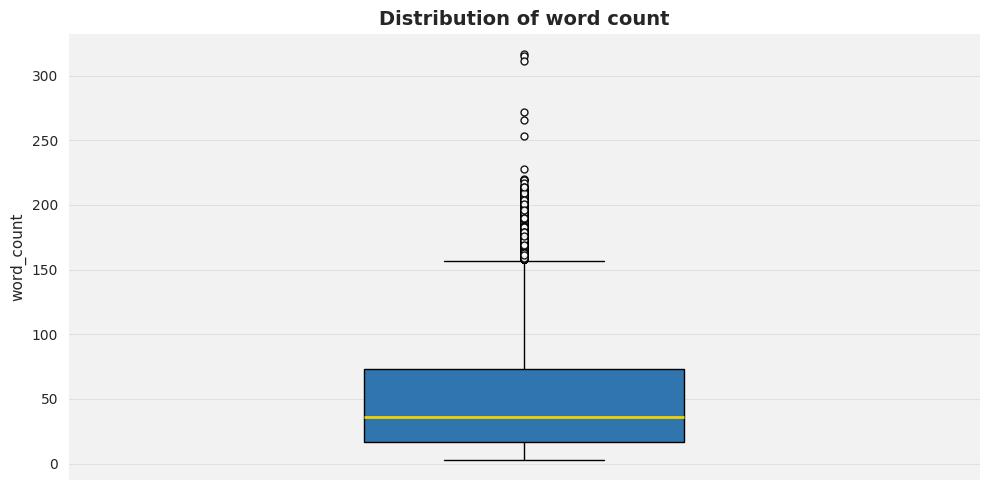


--- Handle outliers using IQR method
=== Jigsaw | Outlier Report (word_count) ===
[✓] Shape before: (1765331, 9)
[✓] Outliers detected: 94219
[✓] Lower bound: -67.0
[✓] Upper bound: 157.0


In [29]:
df_jigsaw_clean = handle_outliers(df_jigsaw, title="Jigsaw", drop_outliers=False)

In [30]:
df_jigsaw_clean.shape

(1765331, 9)


--- Visulaize Outliers using boxplot


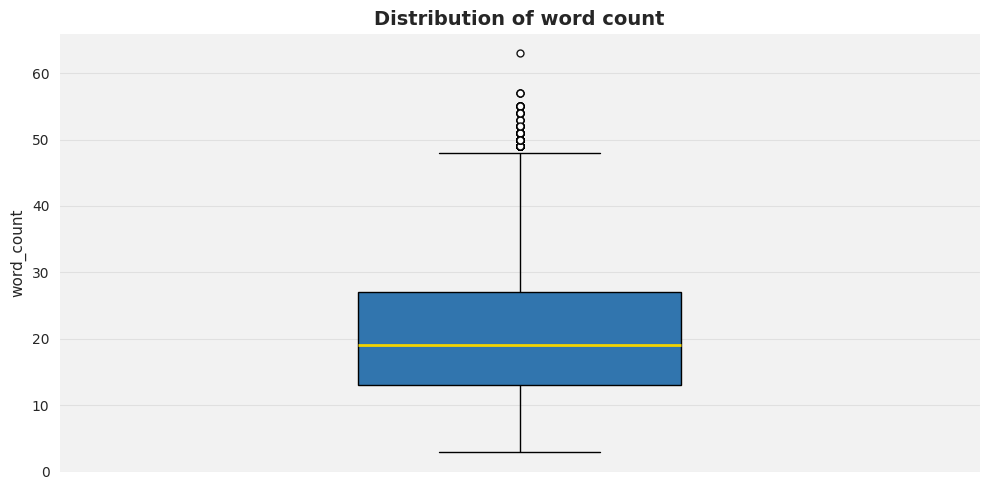


--- Handle outliers using IQR method
=== Twitter | Outlier Report (word_count) ===
[✓] Shape before: (8954, 3)
[✓] Outliers detected: 118
[✓] Lower bound: -8.0
[✓] Upper bound: 48.0


In [31]:
df_twitter_clean = handle_outliers(df_twitter, title="Twitter", drop_outliers=False)

In [32]:
print_table(df_jigsaw_clean.head(10), "Jigsaw Cleaned Dataset")

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit,word_count
0,"This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!",0.000,0.000,0.000,0.000,0.000,0.000,0.000,19
1,"Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!",0.000,0.000,0.000,0.000,0.000,0.000,0.000,22
2,This is such an urgent design problem; kudos to you for taking it on. Very impressive!,0.000,0.000,0.000,0.000,0.000,0.000,0.000,16
3,Is this something I'll be able to install on my site? When will you be releasing it?,0.000,0.000,0.000,0.000,0.000,0.000,0.000,17
4,haha you guys are a bunch of losers.,0.894,0.021,0.000,0.000,0.872,0.021,0.000,8
5,ur a sh*tty comment.,0.667,0.048,0.638,0.000,0.333,0.000,0.010,4
6,hahahahahahahahhha suck it.,0.458,0.051,0.305,0.000,0.254,0.000,0.220,3
8,The ranchers seem motivated by mostly by greed; no one should have the right to allow their animals destroy public land.,0.000,0.000,0.000,0.000,0.000,0.000,0.000,21
9,It was a great show. Not a combo I'd of expected to be good together but it was.,0.000,0.000,0.000,0.000,0.000,0.000,0.000,18
10,"Wow, that sounds great.",0.000,0.000,0.000,0.000,0.000,0.000,0.000,4


In [33]:
print_table(df_twitter_clean.head(10), "Twitter Cleaned Dataset")

,text,label,word_count
0,@user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you…,0,16
1,A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎,1,21
2,@user @user real talk do you have eyes or were they gouged out by a rapefugee?,1,16
3,your girlfriend lookin at me like a groupie in this bitch!,1,11
4,Hysterical woman like @user,0,4
5,Me flirting- So tell me about your father...,0,8
6,"The Philippine Catholic bishops' work for migrant workers should focus on families who are ""paying the great...",0,17
7,I AM NOT GOING AFTER YOUR EX BF YOU LIEING SACK OF SHIT ! I'm done with you dude that's why I dumped your ass cause your a lieing 😂😡 bitch,1,31
8,When cuffin season is finally over,0,6
9,"Send home migrants not in need of protection, Peter Dutton tells UN, HEY DUTTON HOW ABOUT THE ONES THAT HAVE STAYED AND NOT LEFT THE COUNTRY WHEN THEY SHOULD OVERSTAYERS ? WHY DONT YOU GO AND ROUND ALL THEM UP ?",1,41


## Exporting cleaned datasets for EDA

In [34]:
df_jigsaw_clean.to_csv('jigsaw_clean.csv', index=False)

In [35]:
df_twitter_clean.to_csv('twitter_clean.csv', index=False)

# Understanding the data

## Shape of the datasets

### Jigsaw dataset

In [36]:
df_jigsaw_clean = df_jigsaw_clean.drop('word_count',axis = 1)

In [37]:
df_jigsaw_clean.shape

(1765331, 8)

**Inference:**

- Shape of dataframe is 1765331*8
- Number of rows = 1765331
- Number of columns = 8

### Twitter Dataset

In [38]:
df_twitter_clean = df_twitter_clean.drop('word_count',axis = 1)

In [39]:
df_twitter_clean.shape

(8954, 2)

**Inference**:

- Shape of dataframe is  8954*2
- Number of rows = 8954
- Number of columns = 2

## Data types of attributes in the dataset

### Jigsaw dataset

In [40]:
df_jigsaw_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1765331 entries, 0 to 1804873
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   text             object 
 1   toxicity         float32
 2   severe_toxicity  float32
 3   obscene          float32
 4   threat           float32
 5   insult           float32
 6   identity_attack  float32
 7   sexual_explicit  float32
dtypes: float32(7), object(1)
memory usage: 74.1+ MB


**Inference**:

 Jigsaw dataset contains features of two types categorical and numerical. Text feature is of categorical type while rest of the features such as toxicity, severe toxicity, obscene, threat etc are numeric.


### Twitter dataset

In [41]:
df_twitter_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8954 entries, 0 to 8999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8954 non-null   object
 1   label   8954 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 209.9+ KB


**Inference**:

Twitter dataset contains two features text and label. Text is of categorical type and label is of integer type.

## Data Integration

### Combining datasets for eda

In [42]:
df_jigsaw_clean['label'] = (df_jigsaw_clean['toxicity']>=0.5).astype('int')
df_jigsaw_eda = df_jigsaw_clean[['text','label']].copy()
df_jigsaw_eda['source']= 'google'
print_table(df_jigsaw_eda)

,text,label,source
0,"This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!",0,google
1,"Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!",0,google
2,This is such an urgent design problem; kudos to you for taking it on. Very impressive!,0,google
3,Is this something I'll be able to install on my site? When will you be releasing it?,0,google
4,haha you guys are a bunch of losers.,1,google
5,ur a sh*tty comment.,1,google
6,hahahahahahahahhha suck it.,0,google
8,The ranchers seem motivated by mostly by greed; no one should have the right to allow their animals destroy public land.,0,google
9,It was a great show. Not a combo I'd of expected to be good together but it was.,0,google
10,"Wow, that sounds great.",0,google


In [43]:
df_twitter_eda = df_twitter_clean[['text', 'label']].copy()
df_twitter_eda['source'] = 'twitter'
print_table(df_twitter_eda)

,text,label,source
0,@user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you…,0,twitter
1,A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎,1,twitter
2,@user @user real talk do you have eyes or were they gouged out by a rapefugee?,1,twitter
3,your girlfriend lookin at me like a groupie in this bitch!,1,twitter
4,Hysterical woman like @user,0,twitter
5,Me flirting- So tell me about your father...,0,twitter
6,"The Philippine Catholic bishops' work for migrant workers should focus on families who are ""paying the great...",0,twitter
7,I AM NOT GOING AFTER YOUR EX BF YOU LIEING SACK OF SHIT ! I'm done with you dude that's why I dumped your ass cause your a lieing 😂😡 bitch,1,twitter
8,When cuffin season is finally over,0,twitter
9,"Send home migrants not in need of protection, Peter Dutton tells UN, HEY DUTTON HOW ABOUT THE ONES THAT HAVE STAYED AND NOT LEFT THE COUNTRY WHEN THEY SHOULD OVERSTAYERS ? WHY DONT YOU GO AND ROUND ALL THEM UP ?",1,twitter


In [44]:
df_jigsaw_sample = df_jigsaw_eda.sample(n=9000, random_state = 42)

In [45]:
df_eda = pd.concat([df_jigsaw_sample, df_twitter_eda], ignore_index = True)
print_table(df_eda)

,text,label,source
0,"When we refuse to put real, enforceable laws on the books (close the gun show loophole, restrict private sales) regarding the ownership of firearms by mentally ill people, we pay this price. When we send young people off to war without just cause and refuse to adequately care for them when they come home, we pay this price. When we try to confuse the issue by banging on about freedom and resistance to tryanny instead of having an honest discussion about how maybe some people just really shouldn't own firearms, we pay this price. Over and over and over again.",0,google
1,"The old roomy ""high plains drifter"" from Fairbanks or a facsimile?",0,google
2,"Well, let's just stay close to what Jesus said: St Matthew 16: ""Whoever wishes to come after me must deny himself, take up his cross, and follow me."" And ""heart, soul, mind and strength"" If more people would just do a little painful thing every day...such as smiling when they don't want to...how the tone would change.",0,google
3,Oh I'm so sorry for your loss. This makes my heart hurt for your two beautiful dogs. Please be well and guard your team. Such a sad story that as a dog lover I can only imagine........💕😞,0,google
4,"This is true there are people that need to be cared for. Many, not so much.",0,google
5,I just think there is way too much government control. I wonder if there would be the problem with narcotics today if marijuana and other natural substances were not made illegal? I have long felt that making natural drugs like pot illegal only has made problems worse. I guess the house feels we don't need assisted suicide as we already have it witht the second amendment where around 50% of gun deaths are suicides? Believe me I have fears about how our political system has evolved. Democrats used to push for change while republicans stood for the status quo. Now Democrats also tend to stand for the status quo while the republicans want to tear everything down. Shame they no longer have any Eisenhowers.,0,google
6,"Yea and we "" heard stories"" about you also. Grow up idiot",1,google
7,"Impeachment means that the USA will still have 60 million ""poorly educated"" voters ......................... who will become even louder and more ignorant",0,google
8,Your facts are very selective and self serving.,0,google
9,"Normal readers are laughing at, not with the flailing, failing Globe. ▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀ The United States is our closest friend, ally, and by far our largest trading partner. Normal, sensible, healthy Canadians are wishing for America to succeed and prosper under incoming President-Elect Donald Trump. Sad that the Globe would still be spouting spite.",0,google


In [46]:
Print.info("Combined EDA Dataset Shape:", df_eda.shape)

Print.header("Source Distribution:")
Print.success(df_eda['source'].value_counts())

Print.header("Label Distribution:")
Print.success(df_eda['label'].value_counts())

[i] Combined EDA Dataset Shape: (17954, 3)

--- Source Distribution:
[✓] source
google     9000
twitter    8954
Name: count, dtype: int64

--- Label Distribution:
[✓] label
0    13421
1     4533
Name: count, dtype: int64


In [47]:
# Exporting dataset for eda
df_eda.to_csv("eda_combined_dataset.csv", index=False)

### Combining datasets for modelling

In [48]:
df_jigsaw_sample['label'].value_counts()

,count
label,
0,8244
1,756


In [49]:
# sample 50k from google dataset
df_jigsaw_model = (
    df_jigsaw_eda
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=25000, random_state=42))
)
print_table(df_jigsaw_model)

,text,label,source
1720847,"Was the girl on any prescription drugs? If so, perhaps it was one with the side effect 'suicidal thoughts'? If she was on such a drug, would she had been able to do this to herself if she was not on it? Just a thought.",0,google
629761,"While the tax will have an effect, the REAL effect will be if China's new rules regarding taking $ from the country are enforced...that will do way more ""damage"" to the housing market in Vancouver than anything else.",0,google
1243919,"What makes you think I believe the posts in question contain any ""insight and sophistication"" worth defending? The sole intent of my reply was to poke fun at the fact that you're so easily triggered into harrumphing up one of your favorite rants.",0,google
991386,"And so Canada devolves into nonfunctional irrelevance - - - kowtowing to the marginalized interests of any left leaning special interest block that can scratch together enough political capital , cash or PR heat to claim a page five headline - imagine the opposition today to the government of the day announcing a national plan for the initiation of the St Lawrence seaway construction , the national rail-line to the west coast , the James Bay hydro project or the trans Canada highway system........ .............. - - - imagine trying to initiate those programs today- - - - - against the wishes of the first nations - - - against the wishes of the green movement - - - - - against the wishes of the anti energy activists - - - and then try to imagine Canada today without those completed projects - - - What a shameful farce - Post war Bosnia and Serbia have a more functional dynamic",0,google
817295,"boomer 88, a rather defeatist attitude and lame excuse to keep a murderous torturer dictator in power",0,google
130376,"Moody says it all, ""The downgrade recognizes the state's political inability... to address its severe fiscal challenges."" Thanks for nothing Republican controlled Legislature. You've brought us budget deficits four years running, no solutions, and to the edge of an economic precipice. You blew it folks.",0,google
782997,"The white partisans see black. The black partisans see white. What are open minded people to do? When so many don't care for what the truth may be. More interested in who's ""right"" not what's right.",0,google
346104,"I think that the Catholic Church has more serious issue to worry about like being led by a communist Pope who adheres to a godless, totalitarian ideology that, over the last century, has led governments under its yoke to murder over 100 million of their own countries citizens.",0,google
162200,Thanks for posting it Douglas. It's worthy news as another community member passes on.,0,google
1728372,"LW1: In the olden days when it was cheaper to phone family after 7pm and on weekends, my father was the one who called relatives to check on them and offer birthday greetings. Rarely a call back and he was miffed until he died at age 90. Now I am the one who does the one-way cheery check-ins and birthday greetings. We all lead busy lives but email and texting are free and quick. Family used to be important to me but now I expect little from relatives who can't be bothered to respond in kind.",0,google


In [50]:
# remove source columns
df_jigsaw_model = df_jigsaw_model.drop(columns=['source'])
df_twitter_model = df_twitter_eda.drop(columns=['source'])

In [51]:
# combine datasets
df_model = pd.concat(
    [df_jigsaw_model, df_twitter_model],
    axis=0,
    ignore_index=True
)

In [52]:
# shuffle datasets
df_model = df_model.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [53]:
Print.info("Combined Modelling Dataset Shape:", df_model.shape)
Print.header("Label Distribution:")
Print.success(df_model['label'].value_counts())

[i] Combined Modelling Dataset Shape: (58954, 2)

--- Label Distribution:
[✓] label
0    30177
1    28777
Name: count, dtype: int64


In [54]:
# Exporting dataset to csv
df_model.to_csv("combined_model_dataset.csv", index=False)

### Text preprocessing

In [55]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00


In [56]:
def expand_contractions(text):

    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)

    return text

In [57]:
import re
import nltk
import contractions
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
def preprocess(text):
  # expand contractions
  text = contractions.fix(text)

  # lowercase
  text = text.lower()

  # remove mentions
  text = re.sub(r'@\w+', 'USER', text)

  # remove hashtag symbol but keep word
  text = re.sub(r'#', '', text)

  # remove URLs
  text = re.sub(r'http\S+|www\S+', '', text)

  # remove black bars
  text = re.sub(r'█+', ' ', text)

  tokens = nltk.word_tokenize(text)

  tokens = [w for w in tokens if w not in stop_words]
  return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [58]:
df_model["text"] = df_model["text"].apply(preprocess)
print_table(df_model," Dataset overview after text preprocess")

,text,label
0,"obamacare imploring , democrats republican admitted fix needed , michael bennet yelling senate floor . going accomplish anything ? democrats working fix obamacare fix solution health insurance benefit people washington .",0
1,ever catch thieves stole goats north shore ?,0
2,"look , troll ?",1
3,`` revelations meeting come federal prosecutors congressional investigators explore whether trump campaign coordinated encouraged russian efforts intervene election hurt clinton elect trump . '' skittering sound hear ? sounds like rats leaving sinking ship .,1
4,"`` cornyn , r-texas , went way blame democrats cooperating '' . . . joke ? gop would let democrats room , expect concede ?",0
5,"rats smart . quickly become ineffective rats learn `` bait '' good eat . plan b fence around rookeries , fixed cats control re-infestation initial die .",0
6,"way written absolutely uncivil . saying one like , trust , thinks president untruthful-that civil opinion . note : * personal opinion way . 100 % disagree . posting ? uncivil , 'attacking messenger ' , personal bogus info boot . - > `` nominate support lying sociopath run country , well ok. someone actually point nominated support lying sociopath presidency , uncivil . '' < -",0
7,"oh bet black friends . slavery would ended good time . would ww2. , dropped bomb stop death . tell folks marched wit civil rights movement unnecessary black folks would gotten rights sooner later . aunt jemima really someone black heritage wants like , really nice take job family sure could done anything else wanted . bet pay great master families get together sundays dinner church . know sick ? things racist post damned dumb know . good life living ignorant illusion good black folk . aunt jemima , give break . oh yea , sure god wanted folks slaves , kind religion taught ?",1
8,"chi pilialoha guyer maui . going happen islands ? 300 families school age children , disabled vets , seniors living affordable housing complex lahaina , front street apartments ( fsa ) , threatened becoming homeless august 2019 owners complex allowed rent 42 units market rates ( whatever market bear ) . means pay market rents , i.e . $ 1,700 one bedroom unit , evicted streets lahaina august 2019. good solution homelessness ? greatly need help local politicians citizens help get maui county state legislature help `` fix '' problem mandating solutions save folks homelessness . mahalo listening . chi",0
9,"get , referring data analysis data . `` done never enough , even eight years , mostly democrats , charge , trumps fault . '' employ strange logic kd ! said , democrats `` charge '' aspects government 2 last 16 years , let alone 8 years obama administration ! republicans actively opposed renewable energy , regulating pollution anything environmental . often felt democrats slow support things well , least , ultimately , . .... yes , blame republicans standing way regard commonsense environmental regulations every chance got . trump deserves even blame single handedly trying reverse gains made . rate go least environmental president history .",0


In [59]:
def preprocess_bert(text):

    text = re.sub(r'@\w+', 'USER', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'█+', ' ', text)

    return text

### Feature Engineering using TF-IDF

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    lowercase = True,
    stop_words = 'english',
    ngram_range = (1,2),
    min_df = 2,
    max_df = 0.95,
    max_features = 50000,
    token_pattern= r'(?u)\b[a-zA-Z]{2,}\b'

)
X = vectorizer.fit_transform(df_model['text'])
y = df_model['label']
Print.success(X.shape)

[✓] (58954, 50000)


In [61]:
tfidf_sample = pd.DataFrame(
    X[:5].toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_sample

,aa,aa poor,aaa,aap,aap coming,aap rule,aaron,aarp,ab,abandon,...,zoning,zoning laws,zoo,zoolander,zucker,zuckerberg,zuma,zupta,zuptas,zuri
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Dimnensionality reduction using Truncated SVD

**Why we are using truncated singular value decomposition over Principal Component Analysis (PCA) ? for dimensionality reduction ?**

Truncated Singular Value Decomposition (SVD) was used instead of PCA because TF-IDF produces a high-dimensional sparse matrix. PCA requires dense matrices and becomes computationally expensive for large text datasets. Truncated SVD efficiently performs dimensionality reduction directly on sparse matrices and is widely used in text mining applications.

| Method        | Works with sparse TF-IDF | Memory efficient | Recommended for NLP |
| ------------- | ------------------------ | ---------------- | ------------------- |
| PCA           | ❌ No                     | ❌ Poor           | ❌                   |
| Truncated SVD | ✔ Yes                    | ✔ Good           | ✔ Best              |


In [62]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(
    n_components = 200,
    random_state = 42
)

X_svd = svd.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_svd.shape)

Original shape: (58954, 50000)
Reduced shape: (58954, 200)


### Feature Scaling using Standard Scaler

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svd)
X_scaled

array([[-0.19211786,  0.41576641, -0.27497984, ...,  0.40626439,
         3.03896212,  0.8614322 ],
       [-0.43436675, -0.98170027,  0.04605755, ...,  1.55104987,
         0.07833352, -0.75407064],
       [-0.27924347, -0.12097535, -0.25340305, ...,  0.12595065,
        -0.26808576, -0.30721204],
       ...,
       [-0.24145324, -0.05062724, -0.15610201, ...,  0.7468498 ,
         0.29185202, -0.16439561],
       [-0.28100658, -0.18883516, -0.2491703 , ..., -0.77266853,
         1.64529165,  0.57844043],
       [ 1.26297053, -0.28451094,  1.91646809, ...,  0.57810717,
         1.34573879, -0.42278023]])

In [64]:
df_preprocessed = pd.DataFrame(
    X_scaled,
    columns=[f"SVD_{i}" for i in range(X_scaled.shape[1])]
)

In [65]:
df_preprocessed

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_190,SVD_191,SVD_192,SVD_193,SVD_194,SVD_195,SVD_196,SVD_197,SVD_198,SVD_199
0,-0.192118,0.415766,-0.274980,-0.704570,0.887003,0.086860,1.139007,-0.095283,1.575043,0.223000,...,-0.646805,2.090688,1.306552,-1.411309,2.389684,-0.380677,1.496042,0.406264,3.038962,0.861432
1,-0.434367,-0.981700,0.046058,-0.058158,0.014752,0.106106,0.003021,-0.038293,0.087298,-0.067370,...,0.913314,-0.698375,-0.136978,1.084227,-1.220347,-0.473974,-0.606030,1.551050,0.078334,-0.754071
2,-0.279243,-0.120975,-0.253403,0.282433,-0.100127,1.117455,-0.503614,0.585776,-1.098448,0.770529,...,-0.671374,-0.474436,-0.544147,-0.625164,-0.340193,0.967785,0.251289,0.125951,-0.268086,-0.307212
3,-0.063137,1.191437,3.160660,0.760702,-0.930697,2.187501,-0.467284,0.361873,1.020581,-0.252486,...,-0.518158,-1.437479,-0.267298,-0.177985,0.573633,1.448758,-0.772980,-0.728747,-0.171170,-0.193085
4,-0.217609,0.107995,0.138154,-0.226641,0.167750,-0.166470,-0.317830,-0.019659,-0.169644,-0.023311,...,0.237011,-0.272751,1.493499,0.828982,-0.505192,-2.223948,1.910281,-0.313556,1.288073,-0.039705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58949,-0.256292,-1.110208,0.203927,-0.375397,-0.036459,-0.025637,0.009187,-0.175694,0.140789,-0.564663,...,-0.183087,0.088294,0.396351,0.071408,-0.146638,0.219311,0.130708,0.735250,-0.282645,-0.789524
58950,-0.069137,0.514378,1.346518,1.151296,-1.183601,-1.551107,0.046590,0.657334,1.141839,-0.084178,...,-0.500254,-1.460327,1.118280,-0.880131,-1.184834,0.402217,0.117654,0.586922,0.513397,-0.607576
58951,-0.241453,-0.050627,-0.156102,-0.077386,0.077499,0.005144,-0.432479,0.101747,-0.434988,0.474679,...,-0.003048,0.923007,-0.571900,1.541890,-0.265316,-1.190106,-0.656917,0.746850,0.291852,-0.164396
58952,-0.281007,-0.188835,-0.249170,-0.604367,0.129577,-0.266823,-0.598378,-0.057440,0.644148,-0.401028,...,1.278677,2.796695,0.746283,-0.295674,-0.198921,-1.107507,-1.984990,-0.772669,1.645292,0.578440


In [66]:
print_table(df_preprocessed)

In [67]:
df_preprocessed.to_csv("preprocessed_dataset.csv", index=False)

# Basic Statistical Analysis - to be done by Glen


- Compute summary statistics (mean, median, variance, skewness, etc.).

- Explore correlations between features.

- Conduct data similarity and integration analysis if applicable.

## Computing Summary Statistics

In [68]:
twitter_df_summary_clean = pd.read_csv('twitter_clean.csv')
jigsaw_df_summary_clean = pd.read_csv('jigsaw_clean.csv')

# summary statistics for Twitter
twitter_summary_stats = pd.DataFrame()
twitter_summary_stats['Mean'] = twitter_df_summary_clean[['label', 'word_count']].mean()
twitter_summary_stats['Median'] = twitter_df_summary_clean[['label', 'word_count']].median()
twitter_summary_stats['Variance'] = twitter_df_summary_clean[['label', 'word_count']].var()
twitter_summary_stats['Skewness'] = twitter_df_summary_clean[['label', 'word_count']].skew()

print("--- Twitter Dataset Summary Statistics ---")
print(twitter_summary_stats)

# Summary statistics for Jigsaw

jigsaw_numerical_cols = ['toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit', 'word_count']
jigsaw_summary_stats = pd.DataFrame()
jigsaw_summary_stats['Mean'] = jigsaw_df_summary_clean[jigsaw_numerical_cols].mean()
jigsaw_summary_stats['Median'] = jigsaw_df_summary_clean[jigsaw_numerical_cols].median()
jigsaw_summary_stats['Variance'] = jigsaw_df_summary_clean[jigsaw_numerical_cols].var()
jigsaw_summary_stats['Skewness'] = jigsaw_df_summary_clean[jigsaw_numerical_cols].skew()

print("\n--- Jigsaw Dataset Summary Statistics ---")
print(jigsaw_summary_stats)


--- Twitter Dataset Summary Statistics ---
                 Mean  Median    Variance  Skewness
label        0.421823     0.0    0.243916  0.316656
word_count  20.916127    19.0  116.941808  0.749303

--- Jigsaw Dataset Summary Statistics ---
                      Mean  Median     Variance  Skewness
toxicity          0.104398     0.0     0.039137  2.171375
severe_toxicity   0.004641     0.0     0.000529  6.229688
obscene           0.014009     0.0     0.004200  7.253733
threat            0.009458     0.0     0.002477  8.107396
insult            0.082230     0.0     0.031254  2.579755
identity_attack   0.023061     0.0     0.006307  4.797450
sexual_explicit   0.006697     0.0     0.002082  9.769275
word_count       52.250122    36.0  2125.288855  1.229977


## Correlation between features

--- Twitter Correlation ---
               label  word_count
label       1.000000    0.080032
word_count  0.080032    1.000000

--- Jigsaw Correlation ---
                 toxicity  severe_toxicity   obscene    threat    insult  \
toxicity         1.000000         0.392794  0.492261  0.288043  0.927902   
severe_toxicity  0.392794         1.000000  0.338977  0.277698  0.324388   
obscene          0.492261         0.338977  1.000000  0.091220  0.427215   
threat           0.288043         0.277698  0.091220  1.000000  0.108604   
insult           0.927902         0.324388  0.427215  0.108604  1.000000   
identity_attack  0.450773         0.256297  0.124514  0.146466  0.310633   
sexual_explicit  0.252485         0.196549  0.333361  0.088011  0.145070   
word_count       0.003565         0.007672  0.013243 -0.012729  0.006785   

                 identity_attack  sexual_explicit  word_count  
toxicity                0.450773         0.252485    0.003565  
severe_toxicity         0.256297

Text(0.5, 1.0, 'Correlation Matrix - Jigsaw Data')

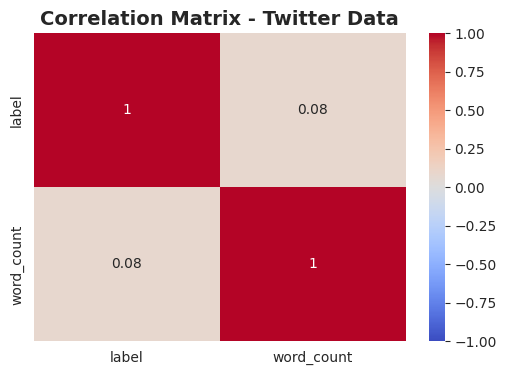

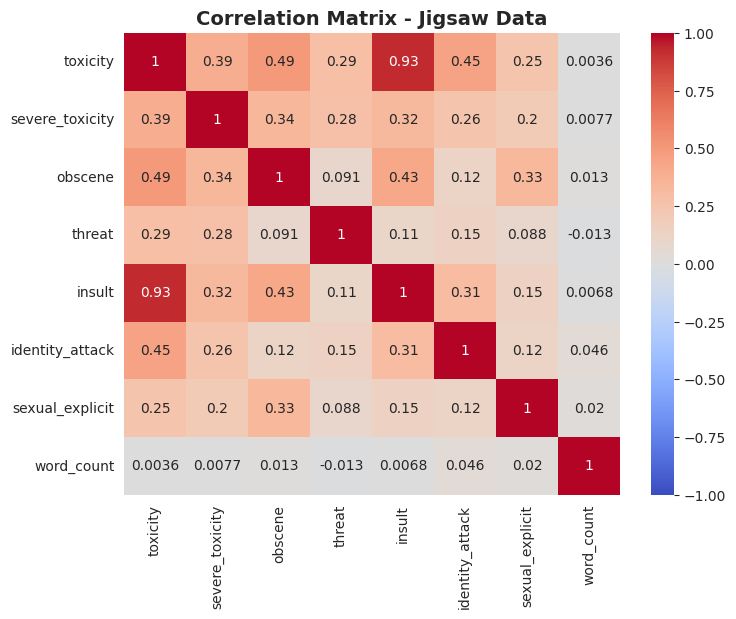

In [69]:
print("--- Twitter Correlation ---")
print(twitter_df_summary_clean[['label', 'word_count']].corr())

# Twitter
plt.figure(figsize=(6, 4))
sns.heatmap(twitter_df_summary_clean[['label', 'word_count']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix - Twitter Data")

# Jigsaw
print("\n--- Jigsaw Correlation ---")
jigsaw_corr = jigsaw_df_summary_clean[jigsaw_numerical_cols].corr()
print(jigsaw_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(jigsaw_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix - Jigsaw Data")


### Based on the summary statistics

**Twitter Dataset**

Our Twitter data looks at two main things: whether a tweet is toxic (the "label") and how long the tweet is.

Toxicity Balance: About 42% of the tweets in our dataset are labeled as toxic. This is a fairly healthy mix, meaning our future model will have plenty of examples of both good and bad behavior to learn from.

Tweet Length: Most tweets are short, around 19 to 21 words. There are a few very long tweets that pull the average slightly higher, but overall, the messages are quick and concise.

**Jigsaw Dataset**

The Jigsaw dataset is structured differently. Instead of a simple "toxic or not" label, it breaks toxicity down into specific categories (like insults, threats, or obscene language).

Rare Behaviors: In this dataset, most of the specific toxic behaviors are rare. The vast majority of comments do not contain severe toxicity or explicit language. Because these negative comments are the exception rather than the rule, we will have to be careful when training our model so it doesn't just blindly guess "not toxic" every time.

Comment Length: Jigsaw comments are much longer than tweets.  The average comment is about 52 words, but the lengths vary wildly, meaning users on this platform tend to write longer, more detailed posts.


### Based on the correlation

**Twitter Dataset**

We checked to see if longer tweets were more likely to be toxic. The relationship between a tweet's length and its toxicity is basically zero. This tells us that toxic behavior happens just as often in a quick 5-word reply as it does in a long paragraph.

**Jigsaw Dataset**

There is a massive overlap between a comment being marked as "toxic" and it containing an "insult." In this dataset, the two are almost identical; insulting language is the number one reason a comment gets flagged as toxic.

Obscene language and identity attacks also frequently show up alongside general toxicity.

Just like with Twitter, the length of a Jigsaw comment has absolutely nothing to do with whether it is toxic or not.

"threats" don't strongly overlap with the other categories. This means someone making a threat might not necessarily be using insults or obscene language to do it.



## Data Similarity and Integration analysis
### Data Merging and Modeling Strategy

- The Google Jigsaw Civil Comments dataset is very large, containing approximately 1.7 million records, whereas the TweetEval Twitter dataset is relatively small with around 9,000 records. In addition, the Civil Comments dataset contains multiple toxicity-related features such as toxicity, severe toxicity, threat, insult, and others, while the Twitter dataset contains only two fields: text and a binary hate label. Because of these differences in dataset size and structure, a suitable data merging strategy is required.

- To make the datasets compatible, the Civil Comments dataset will be converted into a binary classification format by applying the rule toxicity ≥ 0.5 → label = 1 (toxic) and toxicity < 0.5 → label = 0 (non-toxic).

- For Exploratory Data Analysis (EDA), a balanced sample will be used by selecting 9,000 records from the Civil Comments dataset and combining them with the 9,000 records from the Twitter dataset. This balanced subset will allow fair comparison of text characteristics such as vocabulary usage, word distributions, and toxicity patterns.

- For classical machine learning models (Logistic Regression, Naive Bayes, Linear SVM, and LightGBM), a larger dataset will be created by combining 50,000 sampled records from the Civil Comments dataset with the 9,000 Twitter records. To prevent the larger dataset from dominating the smaller Twitter dataset, techniques such as class weighting will be applied so that Twitter examples have greater influence during training.

- For the DistilBERT transformer model, a two-stage training strategy will be applied. First, the model will be trained on 50,000 records from the Civil Comments dataset for one epoch to learn general toxicity language patterns. Next, the model will be fine-tuned on the 9,000 Twitter records for 3–4 epochs, allowing it to adapt to social media language and improve hate speech detection performance.

# Data Quality Assessment

### 1. Completeness, Consistency, and Usability



* **Completeness:** We checked both datasets for missing data. The results showed 0 missing (null) values in both the Jigsaw Civil Comments and Tweet Eval datasets. This means our data is 100% complete.

* **Consistency:** To make sure our models learn properly, we found and removed exact duplicate rows. We dropped 17,955 duplicates from the Jigsaw dataset and 12 from the Twitter dataset, which keeps our data consistent.

* **Usability & Noise Reduction:** For text analysis, very short sentences are not helpful. We removed empty rows and sentences with fewer than 3 words (dropping 21,588 rows from Jigsaw and 34 from Twitter). We also checked for unusually long sentences using the IQR method. We found 94,219 long sentences in Jigsaw and 118 in Twitter, but we decided to keep them because real online comments are naturally varied in length.

### 2. Alignment with Research Objectives




Our main goal is to find toxic comments and hate speech. These two datasets are perfect for this:

* The **Jigsaw Civil Comments** dataset gives us a huge amount of longer community comments. It clearly labels different types of bad behavior, like threats, insults, and identity attacks.

* The **Tweet Eval** dataset gives us short, real-world tweets that are specifically labeled for hate speech.
Using both datasets helps our model understand both long internet discussions and short social media posts.

### 3. Data Ethics, Bias, and Limitations


* **Personal Bias:** Deciding if a comment is "toxic" is often just an opinion. The Jigsaw dataset uses human raters to score the comments, which means the labels are based on those raters' personal backgrounds. What one person thinks is a harsh insult, another might think is just normal slang.

* **Unfairness to Certain Groups:** Text models often unfairly flag the way minorities speak as "toxic." If we train our models on this data, there is a risk that the model will mistakenly label everyday slang from marginalized communities as hate speech.

* **Missing Context:** Social media posts, especially tweets, often lack context. People reply to pictures, videos, or other threads that we cannot see when we only look at the text. Because of this missing background information, our model might easily confuse a sarcastic joke for actual hate speech.

# Advanced Understanding of the data

## Normality check using Q-Q plot

In [70]:
df = df_model.copy()

In [71]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

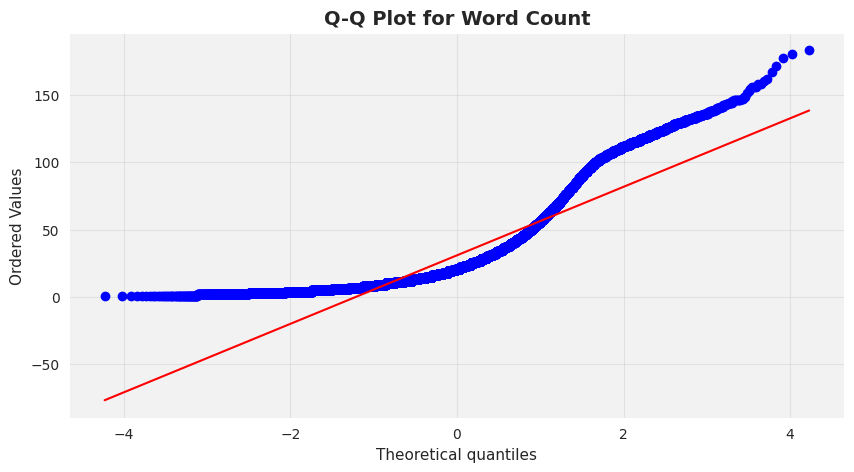

In [72]:
import scipy.stats as stats
stats.probplot(df['word_count'], dist = 'norm', plot = plt)
plt.title("Q-Q Plot for Word Count")
plt.show()

**Inference**:

- The Q–Q plot for the word count feature shows noticeable deviation from the reference line, indicating that the distribution is not normally distributed.
- The distribution is right-skewed, which is expected in text datasets where most comments are short but a few comments contain a large number of words.
- This non-normality does not affect the machine learning models used in this study since they do not assume normally distributed features.